In [1]:
import pandas as pd

df = pd.read_csv("books_raw.csv")

df.head()

,title,category,price,rating,availability,product_description,upc,number_of_reviews,product_url
0,It's Only the Himalayas,Travel,£45.17,Two,In stock (19 available),"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...
1,Libertarianism for Beginners,Politics,£51.33,Two,In stock (19 available),Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,£37.59,One,In stock (19 available),"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...
3,Olio,Poetry,£23.88,One,In stock (19 available),"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...
4,Our Band Could Be Your Life: Scenes from the A...,Music,£57.25,Three,In stock (19 available),This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...


## Raw Dataset Quality Report

This section reports the total scraped records, missing values, and duplicate UPC values, as required in Task 1.

In [2]:
print("Total scraped records:", len(df))

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nDuplicate UPC values:")
print(df["upc"].duplicated().sum())

Total scraped records: 100

Missing values in each column:
title                  0
category               0
price                  0
rating                 0
availability           0
product_description    0
upc                    0
number_of_reviews      0
product_url            0
dtype: int64

Duplicate UPC values:
0


# Book Data Pipeline Using Python and Scrapy

## Student Information

**Name:** Prachi Patel  
**Student ID:** 202618055  
**Course:** DS605 – Fundamentals of Machine Learning  

## Task 1: Data Scraping

This project scrapes book data from Books to Scrape using a Scrapy spider. The spider follows catalogue pagination, visits individual book pages, extracts the required fields, and saves the raw dataset in CSV format.

## Task 2: Data Preprocessing

The raw dataset is cleaned by removing extra spaces, handling missing descriptions, removing duplicate books using UPC, converting price and rating into numeric formats, and extracting the available stock count. New analytical features are then created for further analysis.

In [3]:
# Make a copy of the raw dataset
clean_df = df.copy()

# 1. Clean extra spaces from text columns
text_columns = [
    "title",
    "category",
    "availability",
    "product_description",
    "upc",
    "product_url"
]

for column in text_columns:
    clean_df[column] = (
        clean_df[column]
        .astype("string")
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

# 2. Handle missing descriptions
clean_df["product_description"] = (
    clean_df["product_description"]
    .fillna("No description available")
)

clean_df.loc[
    clean_df["product_description"] == "",
    "product_description"
] = "No description available"

# 3. Remove duplicate books using UPC
records_before = len(clean_df)

clean_df = clean_df.drop_duplicates(
    subset="upc",
    keep="first"
).copy()

records_after = len(clean_df)

# 4. Convert price to numeric
clean_df["price"] = pd.to_numeric(
    clean_df["price"]
    .astype(str)
    .str.replace("£", "", regex=False)
    .str.strip(),
    errors="coerce"
)

# 5. Convert rating words to integers
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

clean_df["rating"] = clean_df["rating"].map(rating_map)

# 6. Extract stock count
clean_df["stock_count"] = (
    clean_df["availability"]
    .str.extract(r"(\d+)\s+available")[0]
)

clean_df["stock_count"] = pd.to_numeric(
    clean_df["stock_count"],
    errors="coerce"
).fillna(0).astype(int)

# Convert review count to integer
clean_df["number_of_reviews"] = pd.to_numeric(
    clean_df["number_of_reviews"],
    errors="coerce"
).fillna(0).astype(int)

# 7. Feature 1: description word count
clean_df["description_word_count"] = (
    clean_df["product_description"]
    .str.split()
    .str.len()
)

# 8. Feature 2: price band
clean_df["price_band"] = pd.cut(
    clean_df["price"],
    bins=[0, 20, 40, float("inf")],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

# 9. Feature 3: affordability score
min_price = clean_df["price"].min()
max_price = clean_df["price"].max()

clean_df["affordability_score"] = (
    100
    * (max_price - clean_df["price"])
    / (max_price - min_price)
).round(2)

# 10. Feature 4: value score
clean_df["value_score"] = (
    clean_df["rating"] / clean_df["price"] * 100
).round(2)

# 11. Feature 5: recommended
median_price = clean_df["price"].median()

clean_df["recommended"] = (
    (clean_df["rating"] >= 4)
    & (clean_df["price"] <= median_price)
    & (clean_df["stock_count"] > 0)
)

# Reset index
clean_df = clean_df.reset_index(drop=True)

# Show preprocessing summary
print("Records before duplicate removal:", records_before)
print("Duplicate records removed:", records_before - records_after)
print("Final cleaned records:", len(clean_df))

print("\nData types:")
print(clean_df[[
    "price",
    "rating",
    "stock_count",
    "number_of_reviews"
]].dtypes)

print("\nMissing values after cleaning:")
print(clean_df.isnull().sum())

clean_df.head()

Records before duplicate removal: 100
Duplicate records removed: 0
Final cleaned records: 100

Data types:
price                float64
rating                 int64
stock_count            int64
number_of_reviews      int64
dtype: object

Missing values after cleaning:
title                     0
category                  0
price                     0
rating                    0
availability              0
product_description       0
upc                       0
number_of_reviews         0
product_url               0
stock_count               0
description_word_count    0
price_band                0
affordability_score       0
value_score               0
recommended               0
dtype: int64


,title,category,price,rating,availability,product_description,upc,number_of_reviews,product_url,stock_count,description_word_count,price_band,affordability_score,value_score,recommended
0,It's Only the Himalayas,Travel,45.17,2,In stock (19 available),"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...,19,230,High,26.99,4.43,False
1,Libertarianism for Beginners,Politics,51.33,2,In stock (19 available),Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...,19,195,High,14.14,3.90,False
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,37.59,1,In stock (19 available),"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...,19,283,Medium,42.79,2.66,False
3,Olio,Poetry,23.88,1,In stock (19 available),"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...,19,249,Medium,71.39,4.19,False
4,Our Band Could Be Your Life: Scenes from the A...,Music,57.25,3,In stock (19 available),This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...,19,163,High,1.79,5.24,False


In [4]:
clean_df.to_csv("books_cleaned.csv", index=False)

print("Cleaned dataset saved as books_cleaned.csv")
print("Cleaned dataset shape:", clean_df.shape)

Cleaned dataset saved as books_cleaned.csv
Cleaned dataset shape: (100, 15)


## Task 3: Visualization and Analysis

This section uses the cleaned dataset to generate summary statistics, four required plots, and a word cloud based on the combined product descriptions.

In [5]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

print("Visualization libraries imported successfully.")

Matplotlib is building the font cache; this may take a moment.


Visualization libraries imported successfully.


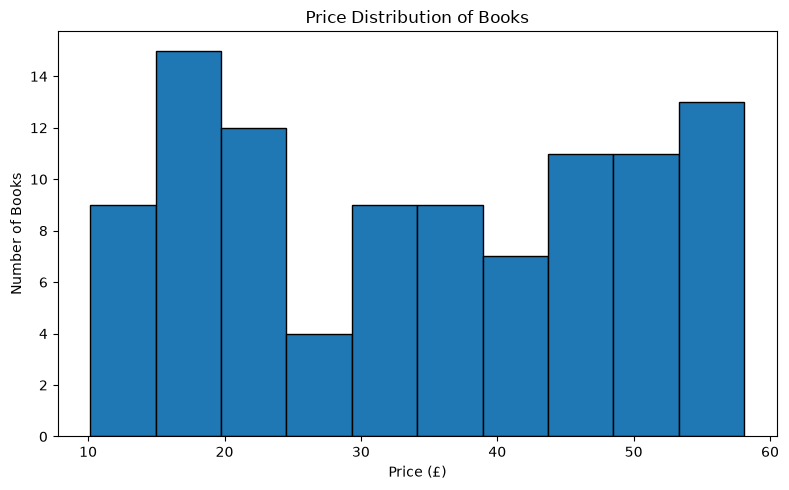

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(clean_df["price"], bins=10, edgecolor="black")

plt.title("Price Distribution of Books")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")

plt.tight_layout()
plt.savefig("price_distribution.png")
plt.show()

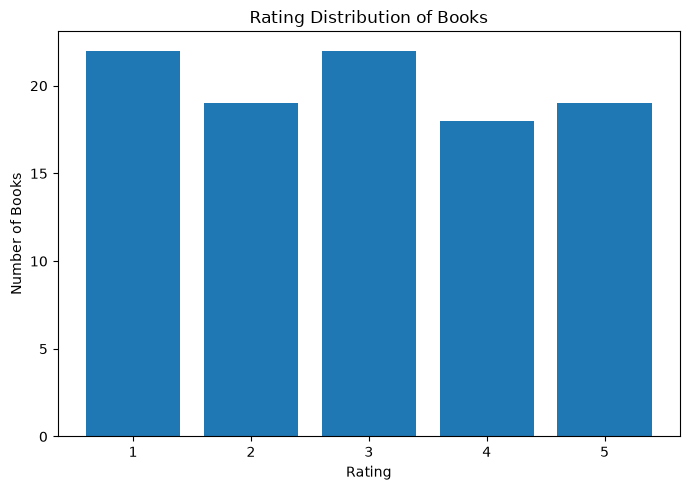

In [7]:
rating_counts = clean_df["rating"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(rating_counts.index, rating_counts.values)

plt.title("Rating Distribution of Books")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.savefig("rating_distribution.png")
plt.show()

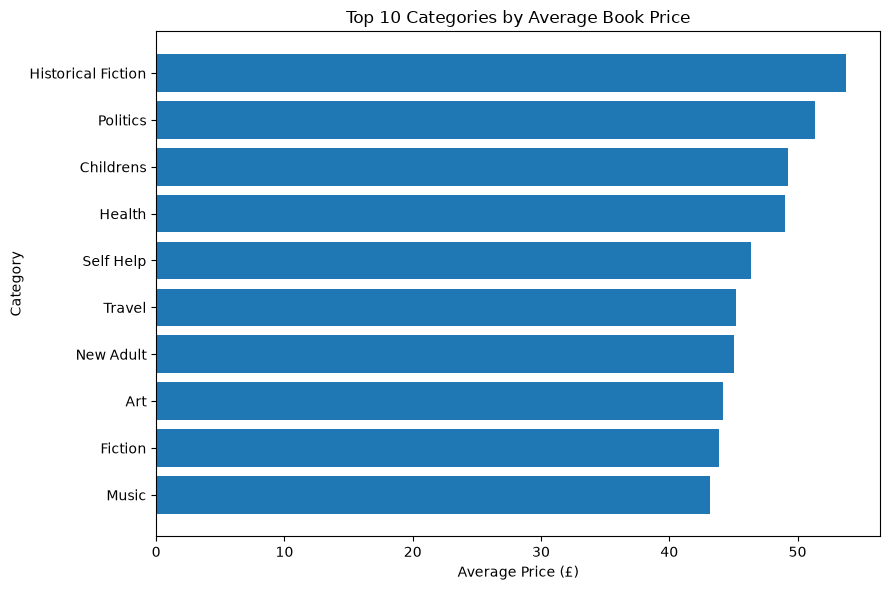

In [8]:
average_price_by_category = (
    clean_df.groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 6))
plt.barh(
    average_price_by_category.index,
    average_price_by_category.values
)

plt.title("Top 10 Categories by Average Book Price")
plt.xlabel("Average Price (£)")
plt.ylabel("Category")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("average_price_by_category.png")
plt.show()

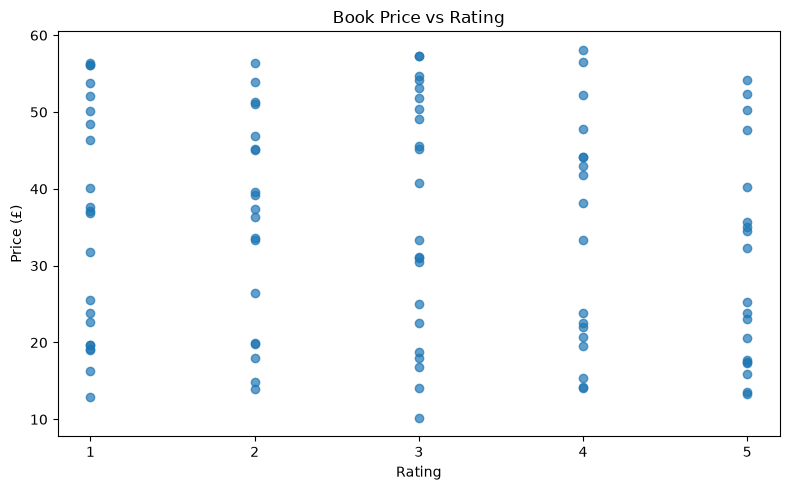

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(
    clean_df["rating"],
    clean_df["price"],
    alpha=0.7
)

plt.title("Book Price vs Rating")
plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.savefig("price_vs_rating.png")
plt.show()

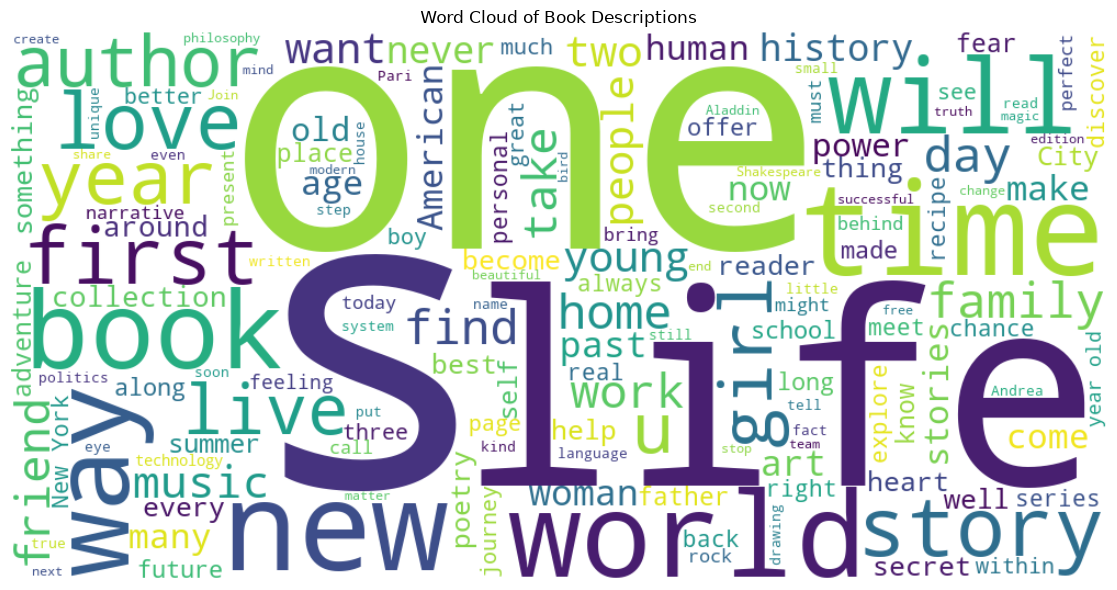

In [10]:
all_descriptions = " ".join(
    clean_df["product_description"].dropna().astype(str)
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=150
).generate(all_descriptions)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Book Descriptions")

plt.tight_layout()
plt.savefig("description_wordcloud.png")
plt.show()

In [11]:
print("Summary statistics:")
display(
    clean_df[
        [
            "price",
            "rating",
            "stock_count",
            "description_word_count",
            "affordability_score",
            "value_score"
        ]
    ].describe().round(2)
)

print("\nTop 10 most represented categories:")
display(
    clean_df["category"]
    .value_counts()
    .head(10)
    .to_frame("book_count")
)

print("\nHighly rated books:")
display(
    clean_df.loc[
        clean_df["rating"] >= 4,
        ["title", "category", "price", "rating", "stock_count"]
    ]
    .sort_values(
        ["rating", "price"],
        ascending=[False, True]
    )
    .head(10)
)

print("\nAverage stock by category:")
display(
    clean_df.groupby("category")["stock_count"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .round(2)
    .to_frame("average_stock")
)

print("\nMissing values in cleaned data:")
display(
    clean_df.isnull()
    .sum()
    .to_frame("missing_count")
)

print("\nPrice-rating correlation:")
print(
    round(
        clean_df["price"].corr(clean_df["rating"]),
        3
    )
)

Summary statistics:


,price,rating,stock_count,description_word_count,affordability_score,value_score
count,100.00,100.00,100.00,100.00,100.00,100.00
mean,34.56,2.93,17.18,224.71,49.11,10.87
std,14.64,1.42,1.48,107.80,30.53,8.49
min,10.16,1.00,16.00,36.00,0.00,1.77
25%,19.90,2.00,16.00,163.75,21.15,5.08
50%,34.78,3.00,16.00,211.50,48.66,8.07
75%,47.97,4.00,19.00,276.50,79.70,14.34
max,58.11,5.00,22.00,722.00,100.00,37.48



Top 10 most represented categories:


,book_count
category,
Sequential Art,14
Nonfiction,12
Default,9
Poetry,7
Food and Drink,5
Add a comment,5
Fiction,5
Young Adult,4
History,4



Highly rated books:


...


Average stock by category:


,average_stock
category,
Historical Fiction,20.00
Business,19.00
Politics,19.00
Romance,19.00
Music,19.00
Travel,19.00
Poetry,18.43
Thriller,18.33
Default,18.11



Missing values in cleaned data:


,missing_count
title,0
category,0
price,0
rating,0
availability,0
product_description,0
upc,0
number_of_reviews,0
product_url,0
stock_count,0



Price-rating correlation:
-0.122


In [13]:
price_rating_correlation = clean_df["price"].corr(clean_df["rating"])

category_counts = clean_df["category"].value_counts()

category_price_summary = (
    clean_df.groupby("category")
    .agg(
        book_count=("title", "count"),
        average_price=("price", "mean")
    )
    .sort_values("average_price", ascending=False)
)

best_value_books = (
    clean_df[
        ["title", "category", "price", "rating", "value_score"]
    ]
    .sort_values("value_score", ascending=False)
    .head(5)
)

print("Average price:", round(clean_df["price"].mean(), 2))
print("Median price:", round(clean_df["price"].median(), 2))
print("Minimum price:", round(clean_df["price"].min(), 2))
print("Maximum price:", round(clean_df["price"].max(), 2))

print("\nRating counts:")
print(clean_df["rating"].value_counts().sort_index())

print("\nPrice-rating correlation:", round(price_rating_correlation, 3))

print("\nMost represented categories:")
display(category_counts.head(10).to_frame("book_count"))

print("\nMost expensive categories:")
display(category_price_summary.head(10).round(2))

print("\nBest value books:")
display(best_value_books)

print("\nStock summary:")
display(clean_df["stock_count"].describe().round(2))

print("\nRecommended books:", int(clean_df["recommended"].sum()))
print("Missing values:", int(clean_df.isnull().sum().sum()))


Average price: 34.56
Median price: 34.78
Minimum price: 10.16
Maximum price: 58.11

Rating counts:
rating
1    22
2    19
3    22
4    18
5    19
Name: count, dtype: int64

Price-rating correlation: -0.122

Most represented categories:


,book_count
category,
Sequential Art,14
Nonfiction,12
Default,9
Poetry,7
Food and Drink,5
Add a comment,5
Fiction,5
Young Adult,4
History,4



Most expensive categories:


,book_count,average_price
category,,
Historical Fiction,1,53.74
Politics,1,51.33
Childrens,3,49.22
Health,1,49.05
Self Help,1,46.35
Travel,1,45.17
New Adult,1,45.07
Art,1,44.18
Fiction,5,43.87



Best value books:


,title,category,price,rating,value_score
82,Princess Between Worlds (Wide-Awake Princess #5),Fantasy,13.34,5,37.48
83,"Princess Jellyfish 2-in-1 Omnibus, Vol. 01 (Pr...",Sequential Art,13.61,5,36.74
21,Sophie's World,Philosophy,15.94,5,31.37
79,Patience,Sequential Art,10.16,3,29.53
37,Thirst,Fiction,17.27,5,28.95



Stock summary:


count    100.00
mean      17.18
std        1.48
min       16.00
25%       16.00
50%       16.00
75%       19.00
max       22.00
Name: stock_count, dtype: float64


Recommended books: 21
Missing values: 0


In [ ]:
## Task 4: Insights and Interpretation

### Key Observations

1. **Book price does not appear to depend on rating.**  
   The correlation between price and rating is -0.122, which is very close to zero. The price-versus-rating plot also shows books from almost every price range at each rating level. This means that expensive books are not necessarily rated better than cheaper books.

2. **The rating distribution is quite balanced.**  
   Ratings 1 and 3 are the most common, with 22 books each. Ratings 2 and 5 each appear 19 times, while rating 4 appears 18 times. Therefore, no single rating dominates the dataset.

3. **Some categories appear much more frequently than others.**  
   Sequential Art is the most represented category with 14 books, followed by Nonfiction with 12 books and Default with 9 books. Poetry contains 7 books, while several other categories contain only one or a few books.

4. **The most expensive categories are based on very small samples.**  
   Historical Fiction has the highest average price at £53.74, followed by Politics at £51.33 and Childrens at £49.22. However, Historical Fiction and Politics each contain only one book in this dataset, so their averages may not represent the overall category accurately.

5. **The best-value books are highly rated and relatively inexpensive.**  
   According to the value score used in this project, *Princess Between Worlds (Wide-Awake Princess #5)* offers the best value. It has a rating of 5, costs £13.34, and has a value score of 37.48. *Princess Jellyfish 2-in-1 Omnibus, Vol. 01* and *Sophie's World* are also among the top-value books.

6. **Stock levels are fairly similar across the dataset.**  
   The number of available copies ranges from 16 to 22, with an average stock count of 17.18. This narrow range suggests that the website uses fairly standardised stock values rather than realistic bookstore inventory behaviour.

7. **The cleaned dataset has good data quality.**  
   No missing values remained after preprocessing, and no duplicate UPC records were found. A total of 21 books were marked as recommended using the rule of high rating, price below the median, and positive stock availability.

### Limitations of the Dataset and Analysis

The dataset was collected from Books to Scrape, which is a practice website rather than a real commercial bookstore. Therefore, its prices, ratings, stock levels, and review counts may not reflect real customer behaviour.

Only 100 books from the first five catalogue pages were analysed. This is only part of the complete website, so the results may change if all available books are included. Some categories contain only one or two books, which makes their average prices less reliable.

The website does not provide written customer reviews. Because of this, product descriptions were used to create the word cloud. The rating values are also demonstration data, so conclusions about the relationship between rating and price should not be treated as real-world consumer findings.

The analysis represents only one point in time. It does not include historical prices, discounts, sales trends, or changes in stock. Finally, the value score used in this project is a custom formula based only on rating and price. It does not measure writing quality, popularity, customer satisfaction, or personal reading preferences.

### Conclusion

The analysis shows that there is no strong relationship between book price and rating. Sequential Art is the most represented category in the sample, while Historical Fiction has the highest average price. The best-value books are mainly books with high ratings and relatively low prices.